In [1]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import os

import pandas as pd

from loaders.measurement import Measurement
from scipy.stats import bootstrap


mpl.rcParams['figure.dpi'] = 175
sns.set_context('paper')
sns.set_palette(sns.color_palette("tab10"))

custom_font_size=8
mpl.rcParams.update({
    'font.size': custom_font_size,
    'axes.labelsize': custom_font_size,
    'axes.titlesize': custom_font_size,
    'legend.title_fontsize': custom_font_size,
    'legend.fontsize': custom_font_size,
    'xtick.labelsize': custom_font_size,
    'ytick.labelsize': custom_font_size,
    'axes.spines.top':    False,
    'axes.spines.right':  False,
    'xtick.top':          False,
    'xtick.bottom':       True,
    'ytick.left':         True,
    'ytick.right':        False,
    'pdf.fonttype':       42,
    'ps.fonttype':        42,
})

acm_column_width = 3.3374
pd.options.display.max_colwidth = 100

# LibWebRTC loading

In [ ]:

paths = ["../data/libwebrtc/aq-starlink",
         "../data/libwebrtc/de-starlink",
         "../data/libwebrtc/nl-starlink",
         "../data/libwebrtc/no-starlink"]

folders = []

for path in paths:
    for folder in [f.path for f in os.scandir(path) if f.is_dir()]:
        folders.append(folder)

measurements_2_5 = dict()
for folder in folders:
    sender_parquet = os.path.join(folder, "sender.parquet")
    receiver_parquet = os.path.join(folder, "receiver.parquet")
    if not (os.path.exists(sender_parquet) and os.path.exists(receiver_parquet)):
        print(f"Skipping {folder}: missing sender.parquet or receiver.parquet")
        continue
    try:
        measurement = Measurement(folder)
        measurement.load_files()
        measurements_2_5[folder] = measurement
    except Exception as e:
        print(f"Warning: {e}")




Loading Dishy data from file: ../data/libwebrtc/aq-starlink/video-LibWebRTC-GCC-h264dashcam-1764857763/dishy_sender.json
Loading Parquet data from file: ../data/libwebrtc/aq-starlink/video-LibWebRTC-GCC-h264dashcam-1764857763/sender.parquet
Loading Parquet data from file: ../data/libwebrtc/aq-starlink/video-LibWebRTC-GCC-h264dashcam-1764857763/receiver.parquet
Loading Dishy data from file: ../data/libwebrtc/aq-starlink/video-LibWebRTC-GCC-h264dashcam-1764994566/dishy_sender.json
Loading Parquet data from file: ../data/libwebrtc/aq-starlink/video-LibWebRTC-GCC-h264dashcam-1764994566/sender.parquet
Loading Parquet data from file: ../data/libwebrtc/aq-starlink/video-LibWebRTC-GCC-h264dashcam-1764994566/receiver.parquet
Loading Dishy data from file: ../data/libwebrtc/aq-starlink/video-LibWebRTC-GCC-h264dashcam-1764951481/dishy_sender.json
Loading Parquet data from file: ../data/libwebrtc/aq-starlink/video-LibWebRTC-GCC-h264dashcam-1764951481/sender.parquet
Loading Parquet data from file: .

In [3]:

def gather_sent_bitrate_samples_trimmed(measurement, resample_ms, trim_start = 30.0, trim_end = 0.0):
    if measurement.data_parquet_sender is None:
        raise ValueError("missing sender parquet data")
    if "OutboundRTP.BytesSent" not in measurement.data_parquet_sender.data:
        return None
    send_vals = measurement.data_parquet_sender.data["OutboundRTP.BytesSent"].resample(f"{resample_ms}ms").max().diff().fillna(0).clip(lower=0)
    send_vals = (send_vals / 1000) * 8 * (1000/resample_ms)
    send_vals.index.name = 'Timestamp'
    send_vals.name = "send_kbps"
    if send_vals is None or send_vals.empty:
        return []
    trim_start_ = pd.Timedelta(seconds=trim_start)
    trim_end_ = pd.Timedelta(seconds=trim_end)
    send_vals = send_vals.loc[send_vals.index.min() + trim_start_ : send_vals.index.max() - trim_end_]
    bitrate_values_mbps = (send_vals.to_numpy() * 0.001).tolist()
    return [v for v in bitrate_values_mbps if np.isfinite(v) and v >= 0]

In [4]:

def gather_recv_bitrate_samples_trimmed(measurement, resample_ms, trim_start = 30.0, trim_end = 0.0):
    if measurement.data_parquet_receiver is None:
        raise ValueError("missing receiver parquet data")
    if "InboundRTP.BytesReceived" not in measurement.data_parquet_receiver.data:
            return None
    recv_vals = measurement.data_parquet_receiver.data["InboundRTP.BytesReceived"].resample(f"{resample_ms}ms").max().diff().fillna(0).clip(lower=0)
    recv_vals = (recv_vals / 1000) * 8 * (1000/resample_ms)
    recv_vals.index.name = 'Timestamp'
    recv_vals.name = "recv_kbps"
    if recv_vals is None or recv_vals.empty:
        return []
    trim_start_ = pd.Timedelta(seconds=trim_start)
    trim_end_ = pd.Timedelta(seconds=trim_end)
    recv_vals = recv_vals.loc[recv_vals.index.min() + trim_start_ : recv_vals.index.max() - trim_end_]
    bitrate_values_mbps = (recv_vals.to_numpy() * 0.001).tolist()
    return [v for v in bitrate_values_mbps if np.isfinite(v) and v >= 0]

In [5]:
def gather_send_fps_samples_trimmed(measurement, trim_start = 30.0, trim_end = 0.0):
    if "OutboundRTP.FramesSent" not in measurement.data_parquet_sender.data:
            return None
    send_fps = measurement.data_parquet_sender.data["OutboundRTP.FramesSent"].resample("1s").max().diff().fillna(0).clip(lower=0)
    send_fps.index.name = 'Timestamp'
    send_fps.name = "send_fps"
    if send_fps is None or send_fps.empty:
        raise ValueError("missing receiver parquet data")
    trim_start_ = pd.Timedelta(seconds=trim_start)
    trim_end_ = pd.Timedelta(seconds=trim_end)
    send_fps = send_fps.loc[send_fps.index.min() + trim_start_ : send_fps.index.max() - trim_end_]
    return send_fps.to_numpy().tolist()

In [6]:
def gather_recv_fps_samples_trimmed(measurement, trim_start = 30.0, trim_end = 0.0):
    if "InboundRTP.FramesReceived" not in measurement.data_parquet_receiver.data:
        return None
    recv_fps = measurement.data_parquet_receiver.data["InboundRTP.FramesReceived"].resample("1s").max().diff().fillna(0).clip(lower=0)
    recv_fps.index.name = 'Timestamp'
    recv_fps.name = "recv_fps"
    if recv_fps is None or recv_fps.empty:
        raise ValueError("missing receiver parquet data")
    trim_start_ = pd.Timedelta(seconds=trim_start)
    trim_end_ = pd.Timedelta(seconds=trim_end)
    recv_fps = recv_fps.loc[recv_fps.index.min() + trim_start_ : recv_fps.index.max() - trim_end_]
    return recv_fps.to_numpy().tolist()

In [7]:
def measurement_parquet_receiver_msm_duration(measurement):
    min_timestamp = pd.Timestamp.max.tz_localize('UTC')
    max_timestamp = pd.Timestamp.min.tz_localize('UTC')
    if measurement.data_parquet_receiver is not None:
        min_v, max_v = measurement.data_parquet_receiver.data.index.min(), measurement.data_parquet_receiver.data.index.max()
        min_timestamp = min(min_timestamp, min_v)
        max_timestamp = max(max_timestamp, max_v)
    if min_timestamp == pd.Timestamp.max.tz_localize('UTC') or max_timestamp == pd.Timestamp.min.tz_localize('UTC'):
        return None
    else:
        return (max_timestamp - min_timestamp).total_seconds()

In [8]:
def get_delay_based_usage(m: Measurement, trim_s=30.0):
    USAGE_MAP = {"underusing": 0, "normal": 1, "overusing": 2}
    if m.data_parquet_sender is not None:
        if "GCCStats.Usage" in m.data_parquet_sender.data:
            usage_series = m.data_parquet_sender.data["GCCStats.Usage"].copy()
            if usage_series.dropna().empty:
                return None
            usage_series.index = ensure_utc_index(usage_series.index)
            if trim_s > 0:
                skip_start = usage_series.index.min() + pd.Timedelta(seconds=trim_s)
                skip_end = usage_series.index.max() - pd.Timedelta(seconds=trim_s)
                usage_series = usage_series.loc[skip_start:skip_end]
                if usage_series.empty:
                    return None
            numeric = usage_series.map(USAGE_MAP)
            numeric.index.name = 'Timestamp'
            numeric.name = "usage"
            return numeric
    return None

In [9]:
resample_ms = 100
trim_start = 30
trim_end = 30

METRICS = {
    "send_bitrate":       lambda m: gather_sent_bitrate_samples_trimmed(m, resample_ms, trim_start, trim_end),
    "recv_bitrate":       lambda m: gather_recv_bitrate_samples_trimmed(m, resample_ms, trim_start, trim_end),
    "send_fps":           lambda m: gather_send_fps_samples_trimmed(m, trim_start, trim_end),
    "recv_fps":           lambda m: gather_recv_fps_samples_trimmed(m, trim_start, trim_end),
}

SITES = {"aq-": "AQ", "de-": "DE", "nl-": "NL", "no-": "NO"}

def site_of(folder):
    return next((v for k, v in SITES.items() if k in folder), None)

def collect(measurements, metrics=METRICS, require_all=True):
    rows, durations, skipped = [], [], []
    for folder, m in measurements.items():
        try:
            vals = {k: fn(m) for k, fn in metrics.items()}
            dur  = measurement_parquet_receiver_msm_duration(m)
        except Exception as exc:
            skipped.append((folder, repr(exc)))
            continue
        missing = [k for k, v in vals.items() if not v]
        if dur is None or (require_all and missing):
            skipped.append((folder, f"missing: {missing or ['duration']}"))
            continue
        for name, v in vals.items():
            rows.append(pd.DataFrame({"value": v, "metric": name, "folder": folder}))
        durations.append({"folder": folder, "duration": dur})
    print(skipped)
    long = pd.concat(rows, ignore_index=True)
    long["location"] = long["folder"].map(site_of)
    dur = pd.DataFrame(durations)
    dur["location"] = dur["folder"].map(site_of)

    print(f"used {dur.shape[0]} folders, skipped {len(skipped)}")
    for f, why in skipped:
        print(f"  {f}: {why}")
    unmatched = long.loc[long.location.isna(), "folder"].unique()
    if len(unmatched):
        print(f"  no site match: {list(unmatched)}")
    return long, dur

df_metrics_2_5_starlink, df_duration_2_5_starlink = collect(measurements_2_5)

[]
used 82 folders, skipped 0


In [10]:
def get_reconfiguration_times(measurement, exclude_handovers=False, handover_tolerance_s=1.0, skip_s=30.0):
    min_ts, max_ts = measurement.data_parquet_sender.data.index.min(), measurement.data_parquet_sender.data.index.max()
    min_ts = ensure_utc_timestamp(min_ts) + pd.Timedelta(seconds=skip_s)
    max_ts = ensure_utc_timestamp(max_ts) - pd.Timedelta(seconds=skip_s)
    reconfig_offsets = [12, 27, 42, 57]
    current_minute = min_ts.floor("min")
    all_reconfigs = []
    while current_minute <= max_ts:
        for offset in reconfig_offsets:
            ts = current_minute + pd.Timedelta(seconds=offset)
            if min_ts <= ts <= max_ts:
                all_reconfigs.append(ts)
        current_minute += pd.Timedelta(minutes=1)

    if not exclude_handovers:
        return all_reconfigs

    handover_timestamps = [ensure_utc_timestamp(ts) for _, ts in measurement.get_handover_times()]
    return [ts for ts in all_reconfigs
            if not any(abs((ts - ho).total_seconds()) < handover_tolerance_s for ho in handover_timestamps)]

In [11]:
groups_2_5 = [
    {"label": "AQ",  "color": "C0", "ls": "solid", "measurements": [m for f, m in measurements_2_5.items() if "aq-" in f]},
    {"label": "DE",  "color": "C1", "ls": "solid", "measurements": [m for f, m in measurements_2_5.items() if "de-" in f]},
    {"label": "NL",  "color": "C2", "ls": "dashed", "measurements": [m for f, m in measurements_2_5.items() if "nl-" in f]},
    {"label": "NO",  "color": "C3", "ls": "dashed", "measurements": [m for f, m in measurements_2_5.items() if "no-" in f]},
]

In [12]:
df_duration_2_5_starlink["day"] = df_duration_2_5_starlink["folder"].apply(lambda x: pd.to_datetime(x.split("-")[-1], unit="s").strftime("%Y-%m-%d"))

/var/folders/ch/9cq6nnj5671_t9s55m2sc0400000gn/T/ipykernel_87518/2646427658.py:1: FutureWarning: The behavior of 'to_datetime' with 'unit' when parsing strings is deprecated. In a future version, strings will be parsed as datetime strings, matching the behavior without a 'unit'. To retain the old behavior, explicitly cast ints or floats to numeric type before calling to_datetime.
  df_duration_2_5_starlink["day"] = df_duration_2_5_starlink["folder"].apply(lambda x: pd.to_datetime(x.split("-")[-1], unit="s").strftime("%Y-%m-%d"))


In [13]:
df_duration_2_5_starlink["month"] = df_duration_2_5_starlink["folder"].apply(lambda x: pd.to_datetime(x.split("-")[-1], unit="s").strftime("%Y-%m"))

/var/folders/ch/9cq6nnj5671_t9s55m2sc0400000gn/T/ipykernel_87518/3038538830.py:1: FutureWarning: The behavior of 'to_datetime' with 'unit' when parsing strings is deprecated. In a future version, strings will be parsed as datetime strings, matching the behavior without a 'unit'. To retain the old behavior, explicitly cast ints or floats to numeric type before calling to_datetime.
  df_duration_2_5_starlink["month"] = df_duration_2_5_starlink["folder"].apply(lambda x: pd.to_datetime(x.split("-")[-1], unit="s").strftime("%Y-%m"))


In [14]:
df_duration_2_5_starlink.groupby("location").agg({"day":lambda x: ",".join(sorted(pd.Series.unique(x)))})

,day
location,
AQ,"2025-12-04,2025-12-05,2025-12-06"
DE,"2026-01-23,2026-01-24,2026-04-29"
NL,"2025-12-23,2025-12-24,2025-12-25,2025-12-26,2025-12-27"
NO,"2025-12-01,2025-12-02"


In [15]:
df_duration_2_5_starlink.groupby("location").agg({"duration": lambda x: sum(x)/3600})

,duration
location,
AQ,5.238544
DE,4.496972
NL,8.744634
NO,1.998453


In [16]:
df_duration_2_5_starlink.groupby(["location", "month"]).agg({"duration": lambda x: sum(x)/3600})

duration
location month            
AQ       2025-12  5.238544
DE       2026-01  3.247538
         2026-04  1.249433
NL       2025-12  8.744634
NO       2025-12  1.998453

In [17]:
def median_ci_df(df, cl=0.95, n_resamples=1000):
    res = bootstrap(
        (df.to_numpy(),),
        lambda x, axis: np.nanmedian(x, axis=axis),
        axis=1,                       # epochs are the columns
        confidence_level=cl,
        n_resamples=n_resamples,
        method="percentile",
    )
    return (df.median(axis=1),
            pd.Series(res.confidence_interval.low,  index=df.index),
            pd.Series(res.confidence_interval.high, index=df.index))

In [18]:
# this function basically slices a dataframe into segments around certain events and resamples all the data so that the time resolution within a segment matches across measurements
def epoch_df(measurements, get_times, before_s, after_s, *,
             column, kind="counter", scale=1.0, side="sender", step_ms=100):
    step   = pd.Timedelta(milliseconds=step_ms)
    lo, hi = pd.Timedelta(seconds=before_s), pd.Timedelta(seconds=after_s)
    grid   = pd.timedelta_range(-lo, hi, freq=step)
    step_s = step_ms / 1000

    cols = []
    for m in measurements:
        data = getattr(m, f"data_parquet_{side}")
        if data is None or column not in data.data:
            continue
        s = data.data[column].dropna()
        if len(s) < 2:
            continue

        events = get_times(m)
        if not events:
            continue

        # Resample aligned to the first event and not to msm start
        first = ensure_utc_timestamp(events[0])
        if kind == "counter":
            r = s.resample(step, origin=first).max().diff().where(lambda x: x >= 0) / step_s * scale
        else:
            r = s.resample(step, origin=first).mean() * scale

        # Slice per event, the above alignment guarantees that the bins between measurements are aligned
        for t0 in events:
            t0 = ensure_utc_timestamp(t0)
            seg = r.loc[t0 - lo : t0 + hi]
            if len(seg) < 2:
                continue
            seg = seg.copy()
            seg.index = seg.index - t0
            cols.append(seg.reindex(grid))

    return pd.concat(cols, axis=1) if cols else None

In [19]:
def ensure_utc_timestamp(ts):
    """Make sure a single Timestamp is UTC."""
    return ts.tz_localize("UTC") if ts.tzinfo is None else ts.tz_convert("UTC")
def ensure_utc_index(index):
    """Make sure a DatetimeIndex is UTC."""
    return index.tz_localize("UTC") if index.tz is None else index.tz_convert("UTC")

AQ
0.18008000000000024
DE
0.1535599999999997
NL
0.12211999999999978
NO
0.3113600000000001


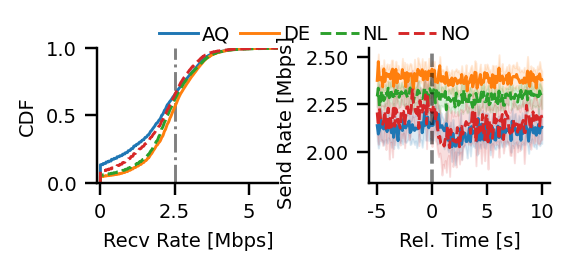

In [ ]:
WINDOW_BEFORE = 5
WINDOW_AFTER = 10
GRID_STEP = 0.1


fig, axs = plt.subplots(1, 2, figsize=(acm_column_width, 1))

legend_items = ['AQ', 'DE', 'NL', 'NO']
labels_short = {
    "NL": "NL",
    "NO": "NO",
    "DE": "DE",
    "AQ": "AQ"
}

linestyles = ["solid", "solid", "dashed", "dashed"]

for color_index, location in enumerate(legend_items):
    axs[0].ecdf(df_metrics_2_5_starlink[(df_metrics_2_5_starlink.location == location) & (df_metrics_2_5_starlink.metric == "recv_bitrate")]["value"], label=labels_short[location], color="C"+str(color_index), ls=linestyles[color_index])

# Left: CDF of bitrate
axs[0].set_xlim(left=-0.1, right=6)
axs[0].set_xlabel("Recv Rate [Mbps]")
axs[0].set_ylabel("CDF")
axs[0].axvline(2.5, color="gray", ls="-.", zorder=-1)


axs[0].legend(loc='center', frameon=False, handletextpad=0.2, bbox_to_anchor=(1.2,1.1), ncols=4, columnspacing=0.5)

# Right: relative sending rate around all reconfigurations
WINDOW_BEFORE = 5
WINDOW_AFTER = 10
GRID_STEP = 0.1
handover_window_s = 1.0 # not used
skip_s = 30.0

for g in groups_2_5:
    SEND_MBPS = dict(column="OutboundRTP.BytesSent", kind="counter", scale=8e-6, side="sender", step_ms=GRID_STEP*1000)
    df = epoch_df(g["measurements"], lambda m: get_reconfiguration_times(m, exclude_handovers=False, handover_tolerance_s=handover_window_s, skip_s=skip_s,), WINDOW_BEFORE, WINDOW_AFTER, **SEND_MBPS)
    median, ci_lo, ci_hi = median_ci_df(df)
    print(g["label"])
    print(pd.Series(median).max()-pd.Series(median).min()) # bitrate drop
    t = median.index.total_seconds()
    axs[1].plot(t, median.values, label=labels_short[g["label"]], color=g["color"], ls=g["ls"])
    axs[1].fill_between(t, ci_lo.values, ci_hi.values, color=g["color"], alpha=0.15)

axs[1].axvline(0, color="black", linewidth=1.5, alpha=0.5, linestyle="--")

axs[1].set_xlabel("Rel. Time [s]")
axs[1].set_ylabel("Send Rate [Mbps]", y=0.45) # computer modern sans is sort of hardcoded here
axs[0].set_xticks([0,2.5,5],labels=["0","2.5","5"])
axs[1].set_xticks([-5,0,5,10],labels=["-5","0","5","10"])

fig.subplots_adjust(wspace=0.5)
plt.savefig('libwebrtc-geo-2_5.pdf', bbox_inches='tight', pad_inches=0)
plt.show()

AQ
loss state changes: 90
delay state changes: 140
DE
loss state changes: 33
delay state changes: 35
NL
loss state changes: 110
delay state changes: 78
NO
loss state changes: 144
delay state changes: 78


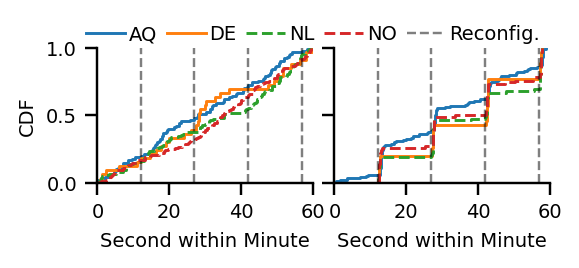

In [21]:
labels_short = {
    "NL": "NL",
    "NO": "NO",
    "DE": "DE",
    "AQ": "AQ"
}

fig, (ax_state, ax_usage) = plt.subplots(1, 2, sharey=True, figsize=(acm_column_width, 1))

for g in groups_2_5:
    measurements = g["measurements"]
    print(g["label"])
    loss_state_change_counter = 0
    delay_state_change_counter = 0

    # Left: loss state → decreasing
    seconds_state = []
    for m in measurements:
        if m.data_parquet_sender is None:
            continue
        if "GCCStats.State" not in m.data_parquet_sender.data:
            continue
        state = m.data_parquet_sender.data["GCCStats.State"]
        idx = ensure_utc_index(state.index)
        state = state.copy()
        state.index = idx
        skip_start = state.index.min() + pd.Timedelta(seconds=30)
        skip_end = state.index.max() - pd.Timedelta(seconds=30)
        state = state.loc[skip_start:skip_end]
        prev = state.shift(1)
        edges = state.index[(prev != "decreasing") & (state == "decreasing")]
        loss_state_change_counter = loss_state_change_counter + len(edges)
        for edge_ts in edges:
            seconds_state.append(edge_ts.second + edge_ts.microsecond / 1e6)

    if seconds_state:
        ax_state.ecdf(seconds_state, label=labels_short[g["label"]], color=g["color"], ls=g["ls"])

    # Right: usage normal → overusing
    seconds_usage = []
    for m in measurements:
        usage = get_delay_based_usage(m)
        if usage is None:
            continue
        prev = usage.shift(1)
        edges = usage.index[(prev == 1) & (usage == 2)]
        delay_state_change_counter = delay_state_change_counter + len(edges)
        for edge_ts in edges:
            seconds_usage.append(edge_ts.second + edge_ts.microsecond / 1e6)

    if seconds_usage:
        ax_usage.ecdf(seconds_usage, label=labels_short[g["label"]], color=g["color"], ls=g["ls"])

    print(f"loss state changes: {loss_state_change_counter}")
    print(f"delay state changes: {delay_state_change_counter}")


for ax in (ax_state, ax_usage):
    for offset in [12, 27, 42, 57]:
        ax.axvline(offset, color="black", linewidth=1.0, alpha=0.5, linestyle="--",
                   label="Reconfig." if offset == 12 else None)
    ax.set_xlim(0, 60)
    ax.set_xlabel("Second within Minute")

ax_state.set_ylabel("CDF")
ax_usage.tick_params(labelleft=False)

ax_state.legend(loc='center', frameon=False, handletextpad=0.2, bbox_to_anchor=(1,1.1), ncols=5, columnspacing=0.5)
fig.subplots_adjust(wspace=0.1)
plt.savefig('libwebrtc-geo-2_5_estimator_state.pdf', bbox_inches='tight', pad_inches=0)
plt.show()

In [22]:
for g in groups_2_5:
    measurements = g["measurements"]
    
    total_seconds = 0
    delay_based_seconds = 0
    
    for m in measurements:
        if m.data_parquet_sender is None:
            continue
        if "GCCStats.State" not in m.data_parquet_sender.data:
            continue
        state = m.data_parquet_sender.data["GCCStats.State"].copy()
        state.index = ensure_utc_index(state.index)
        
        skip_start = state.index.min() + pd.Timedelta(seconds=30)
        skip_end = state.index.max() - pd.Timedelta(seconds=30)
        state = state.loc[skip_start:skip_end]
        if state.empty:
            continue
        
        dt = state.index.to_series().diff().dt.total_seconds().fillna(0)
        total_seconds += dt.sum()
        delay_based_seconds += dt[state == "delay_based_estimate"].sum()
    
    if total_seconds > 0:
        print(f"{g['label']}: {delay_based_seconds:.1f}s / {total_seconds:.0f}s = {100 * delay_based_seconds / total_seconds:.1f}% in delay_based_estimate")

AQ: 17422.2s / 17606s = 99.0% in delay_based_estimate
DE: 15044.6s / 15109s = 99.6% in delay_based_estimate
NL: 29110.8s / 29380s = 99.1% in delay_based_estimate
NO: 6470.9s / 6714s = 96.4% in delay_based_estimate


In [23]:
for g in groups_2_5:
    measurements = g["measurements"]
    
    total_seconds = 0
    overuse_seconds = 0
    
    for m in measurements:
        usage = get_delay_based_usage(m)
        if usage is None:
            continue
        
        dt = usage.index.to_series().diff().dt.total_seconds().fillna(0)
        total_seconds += dt.sum()
        overuse_seconds += dt[usage == 2].sum()
    
    non_overuse_s = total_seconds - overuse_seconds
    print(f"{g['label']}: total={total_seconds:.0f}s, overuse={overuse_seconds:.1f}s ({100*overuse_seconds/total_seconds:.2f}%), non-overuse={non_overuse_s:.0f}s ({100*non_overuse_s/total_seconds:.2f}%)")

AQ: total=17606s, overuse=68.4s (0.39%), non-overuse=17537s (99.61%)
DE: total=15109s, overuse=9.9s (0.07%), non-overuse=15099s (99.93%)
NL: total=29380s, overuse=19.7s (0.07%), non-overuse=29360s (99.93%)
NO: total=6714s, overuse=26.6s (0.40%), non-overuse=6688s (99.60%)


In [25]:


tolerance_s = 1.0
reconfig_offsets = [12, 27, 42, 57]

categories = ["Reconfig (no handover)", "Irregular handover", "Handover at reconfig", "Unattributed"]

for vp_idx, vp in enumerate(groups_2_5):
    measurements = vp["measurements"]

    durations_by_category = {cat: [] for cat in categories}
    total_edges = 0

    for m in measurements:
        usage = get_delay_based_usage(m)
        if usage is None:
            continue
        idx = ensure_utc_index(usage.index)
        usage = usage.copy()
        usage.index = idx

        prev = usage.shift(1)
        edges = list(usage.index[(prev == 1) & (usage == 2)])
        if not edges:
            continue
        total_edges += len(edges)

        reconfig_times = [ensure_utc_timestamp(ts) for ts in get_reconfiguration_times(m)]
        handover_times = [ensure_utc_timestamp(ts) for _, ts in m.get_handover_times()]

        for edge_ts in edges:
            nearest_ho = None
            nearest_ho_dist = float('inf')
            for ho in handover_times:
                dist = abs((edge_ts - ho).total_seconds())
                if dist < nearest_ho_dist:
                    nearest_ho_dist = dist
                    nearest_ho = ho

            is_near_reconfig = any(abs((edge_ts - ts).total_seconds()) < tolerance_s for ts in reconfig_times)
            is_near_handover = nearest_ho_dist < tolerance_s

            if is_near_handover:
                sec = nearest_ho.second + nearest_ho.microsecond / 1e6
                ho_is_regular = any(abs(sec - o) < tolerance_s for o in reconfig_offsets)
                if ho_is_regular:
                    cat = "Handover at reconfig"
                else:
                    cat = "Irregular handover"
            elif is_near_reconfig:
                cat = "Reconfig (no handover)"
            else:
                cat = "Unattributed"

            remaining = usage.loc[edge_ts:]
            not_overuse = remaining != 2
            if not_overuse.any():
                duration = (not_overuse.idxmax() - edge_ts).total_seconds()
            else:
                duration = (remaining.index[-1] - edge_ts).total_seconds()
            durations_by_category[cat].append(duration)

    print(f"=== {vp['label']} ===")
    print(f"  Total rising edges (normal→overuse): {total_edges}")
    for cat in categories:
        durations = durations_by_category[cat]
        if durations:
            print(f"  {cat}: {len(durations)} ({100 * len(durations) / total_edges:.1f}%), median={np.median(durations):.3f}s, P95={np.percentile(durations, 95):.3f}s")
        else:
            print(f"  {cat}: no episodes")
    print()

=== AQ ===
  Total rising edges (normal→overuse): 140
  Reconfig (no handover): 25 (17.9%), median=0.257s, P95=0.852s
  Irregular handover: 21 (15.0%), median=0.308s, P95=1.031s
  Handover at reconfig: 39 (27.9%), median=0.359s, P95=1.261s
  Unattributed: 55 (39.3%), median=0.360s, P95=1.496s

=== DE ===
  Total rising edges (normal→overuse): 35
  Reconfig (no handover): 5 (14.3%), median=0.203s, P95=0.365s
  Irregular handover: 3 (8.6%), median=0.304s, P95=0.532s
  Handover at reconfig: 27 (77.1%), median=0.253s, P95=0.511s
  Unattributed: no episodes

=== NL ===
  Total rising edges (normal→overuse): 78
  Reconfig (no handover): 24 (30.8%), median=0.207s, P95=0.562s
  Irregular handover: 1 (1.3%), median=0.207s, P95=0.207s
  Handover at reconfig: 51 (65.4%), median=0.219s, P95=0.448s
  Unattributed: 2 (2.6%), median=0.263s, P95=0.408s

=== NO ===
  Total rising edges (normal→overuse): 78
  Reconfig (no handover): 26 (33.3%), median=0.255s, P95=0.675s
  Irregular handover: 1 (1.3%), m

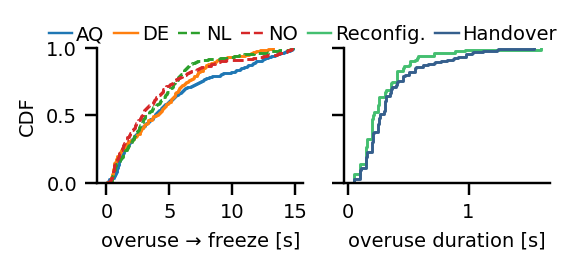

In [27]:

cmap = plt.cm.viridis
color_1 = cmap(0.3)
color_2 = cmap(0.7)
tmp_palette = [color_2, color_1]

fig, (ax_left, ax_right) = plt.subplots(1, 2, sharey=True, figsize=(acm_column_width, 1))

# Left: overuse → freeze
for g in groups_2_5:
    delays = []
    for m in g["measurements"]:
        if m.data_parquet_receiver is None:
            continue
        d = m.data_parquet_receiver.data
        if "InboundRTP.TotalFreezesDuration" not in d:
            continue
        freezes = d["InboundRTP.TotalFreezesDuration"].copy()
        freezes.index = ensure_utc_index(freezes.index)
        freeze_diff = freezes.diff().fillna(0).clip(lower=0)
        freeze_events = list(freeze_diff.index[freeze_diff > 0])
        
        usage = get_delay_based_usage(m)
        if usage is None:
            continue
        prev = usage.shift(1)
        overuse_edges = list(usage.index[(prev == 1) & (usage == 2)])
        
        for freeze_ts in freeze_events:
            preceding = [e for e in overuse_edges if e < freeze_ts]
            if not preceding:
                continue
            last_overuse = preceding[-1]
            following = [e for e in overuse_edges if e > last_overuse]
            next_overuse_delay = (following[0] - last_overuse).total_seconds() if following else float('inf')
            max_delay = min(next_overuse_delay, 15)
            delay = (freeze_ts - last_overuse).total_seconds()
            if delay < max_delay:
                delays.append(delay)
    
    if delays:
        ax_left.ecdf(delays, color=g["color"], ls=g["ls"], label=g["label"])

ax_left.set_xticks(ticks=[0,5,10,15], labels=["0", "5", "10", "15"])
ax_left.set_xlabel("overuse → freeze [s]")
ax_left.set_ylabel("CDF")

# Right: handover vs reconfig aggregated
all_handover = []
all_reconfig = []

for g in groups_2_5:
    for m in g["measurements"]:
        usage = get_delay_based_usage(m)
        if usage is None:
            continue
        prev = usage.shift(1)
        edges = list(usage.index[(prev == 1) & (usage == 2)])
        if not edges:
            continue
        reconfig_times = [ensure_utc_timestamp(ts) for ts in get_reconfiguration_times(m)]
        handover_times = [ensure_utc_timestamp(ts) for _, ts in m.get_handover_times()]
        
        for edge_ts in edges:
            nearest_ho_dist = min((abs((edge_ts - ho).total_seconds()) for ho in handover_times), default=float('inf'))
            is_near_reconfig = any(abs((edge_ts - ts).total_seconds()) < 1.0 for ts in reconfig_times)
            is_near_handover = nearest_ho_dist < 1.0
            
            remaining = usage.loc[edge_ts:]
            not_overuse = remaining != 2
            if not_overuse.any():
                duration = (not_overuse.idxmax() - edge_ts).total_seconds()
            else:
                duration = (remaining.index[-1] - edge_ts).total_seconds()
            
            if is_near_handover:
                all_handover.append(duration)
            elif is_near_reconfig:
                all_reconfig.append(duration)
                
ax_right.ecdf(all_reconfig, color=tmp_palette[0], label=f"RC (n={len(all_reconfig)})")
ax_right.ecdf(all_handover, color=tmp_palette[1], label=f"HO (n={len(all_handover)})")

ax_right.set_xlabel("overuse duration [s]")

legend_handles = [
    mpl.lines.Line2D([0], [0], color=g["color"], label=g["label"], markersize=0, lw=1, ls=g["ls"])
    for g in groups_2_5
] + [
            mpl.lines.Line2D([0], [0], color=tmp_palette[0], label="Reconfig.", lw=1),
            mpl.lines.Line2D([0], [0], color=tmp_palette[1], label="Handover", lw=1),
        ]

ax_left.legend(handles=legend_handles, loc='center', frameon=False, handletextpad=0.2, bbox_to_anchor=(1,1.1), ncols=6, columnspacing=0.5, handlelength=1.2)

plt.savefig('libwebrtc-overuse.pdf', bbox_inches='tight', pad_inches=0)
plt.show()

In [28]:
measurements = [m for f, m in measurements_2_5.items() if "de-" in f]

total_duration_s = 0
overuse_duration_s = 0
decreasing_duration_s = 0

for m in measurements:
    usage = get_delay_based_usage(m)
    if usage is None:
        continue
    
    dt = usage.index.to_series().diff().dt.total_seconds().fillna(0)
    total_duration_s += dt.sum()
    overuse_duration_s += dt[usage == 2].sum()
    
    if m.data_parquet_sender is not None and "GCCStats.State" in m.data_parquet_sender.data:
        state = m.data_parquet_sender.data["GCCStats.State"]
        state = state.copy()
        state.index = ensure_utc_index(state.index)
        skip_start = state.index.min() + pd.Timedelta(seconds=30)
        skip_end = state.index.max() - pd.Timedelta(seconds=30)
        state = state.loc[skip_start:skip_end]
        dt_state = state.index.to_series().diff().dt.total_seconds().fillna(0)
        decreasing_duration_s += dt_state[state == "decreasing"].sum()

print("DE 2.5 Mbps")
print(f"  Total duration:      {total_duration_s:.0f}s ({total_duration_s/3600:.1f}h)")
print(f"  Delay overuse:       {overuse_duration_s:.1f}s ({100 * overuse_duration_s / total_duration_s:.2f}%)")
print(f"  Loss decreasing:     {decreasing_duration_s:.1f}s ({100 * decreasing_duration_s / total_duration_s:.2f}%)")

DE 2.5 Mbps
  Total duration:      15109s (4.2h)
  Delay overuse:       9.9s (0.07%)
  Loss decreasing:     37.2s (0.25%)


AQ
  Reconfig→overuse: n=106, P50=1.068s, P90=3.304s
DE
  Reconfig→overuse: n=35, P50=0.443s, P90=0.666s
NL
  Reconfig→overuse: n=73, P50=0.399s, P90=0.656s
NO
  Reconfig→overuse: n=72, P50=0.534s, P90=0.717s


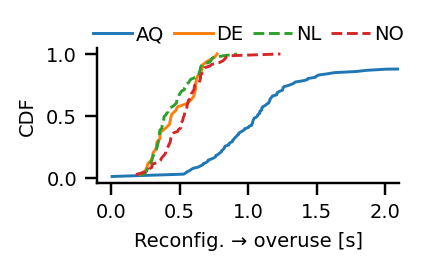

In [30]:
fig, ax_reconfig_to_overuse = plt.subplots(1, 1, figsize=(acm_column_width*2/3, 1))

for vp in groups_2_5:
    measurements = vp["measurements"]
    
    reconfig_to_overuse = []
    
    for m in measurements:
        usage = get_delay_based_usage(m)
        if usage is None:
            continue
        
        idx = ensure_utc_index(usage.index)
        usage = usage.copy()
        usage.index = idx
        
        # Find overuse edges
        prev = usage.shift(1)
        overuse_edges = list(usage.index[(prev == 1) & (usage == 2)])
        
        reconfig_times = [ensure_utc_timestamp(ts) for ts in get_reconfiguration_times(m)]
        
        for edge_ts in overuse_edges:
            preceding_reconfigs = [ts for ts in reconfig_times if ts <= edge_ts]
            if not preceding_reconfigs:
                continue
            nearest_reconfig = preceding_reconfigs[-1]
            dt_reconfig = (edge_ts - nearest_reconfig).total_seconds()
            if 0 <= dt_reconfig < 5:
                reconfig_to_overuse.append(dt_reconfig)
            
    
    if reconfig_to_overuse:
        sorted_d = np.sort(reconfig_to_overuse)
        cdf = np.arange(1, len(sorted_d) + 1) / len(sorted_d)
        ax_reconfig_to_overuse.plot(sorted_d, cdf, color=vp["color"], label=vp["label"], ls=vp["ls"])
        print(vp['label'])
        print(f"  Reconfig→overuse: n={len(reconfig_to_overuse)}, P50={np.percentile(reconfig_to_overuse, 50):.3f}s, P90={np.percentile(reconfig_to_overuse, 90):.3f}s")
    
ax_reconfig_to_overuse.legend(loc='center', frameon=False, handletextpad=0.2, bbox_to_anchor=(0.5,1.1), ncols=6, columnspacing=0.5)
ax_reconfig_to_overuse.set_xlabel("Reconfig. → overuse [s]")
ax_reconfig_to_overuse.set_ylabel("CDF")

ax_reconfig_to_overuse.set_xlim(-0.1,2.1)
#fig.subplots_adjust(wspace=0.45)
plt.savefig('libwebrtc-reconfig-to-overuse.pdf', bbox_inches='tight', pad_inches = 0)
plt.show()

# 10 Mbps


In [31]:

paths = ["../data/libwebrtc-and-pion/de-libwebrtc-10/"]

folders = []

for path in paths:
    for folder in [f.path for f in os.scandir(path) if f.is_dir()]:
        folders.append(folder)

measurements_10= dict()
for folder in folders:
    sender_parquet = os.path.join(folder, "sender.parquet")
    receiver_parquet = os.path.join(folder, "receiver.parquet")
    if not (os.path.exists(sender_parquet) and os.path.exists(receiver_parquet)):
        print(f"Skipping {folder}: missing sender.parquet or receiver.parquet")
        continue
    try:
        measurement = Measurement(folder)
        measurement.load_files()
        measurements_10[folder] = measurement
    except Exception as e:
        print(f"Warning: {e}")




Loading Dishy data from file: ../data/libwebrtc-and-pion/de-libwebrtc-10/video-LibWebRTC-GCC-h264-10000-1769225438/dishy_sender.json
Loading IRTT data from file: ../data/libwebrtc-and-pion/de-libwebrtc-10/video-LibWebRTC-GCC-h264-10000-1769225438/irtt-sender.json
Loading Parquet data from file: ../data/libwebrtc-and-pion/de-libwebrtc-10/video-LibWebRTC-GCC-h264-10000-1769225438/sender.parquet
Loading Parquet data from file: ../data/libwebrtc-and-pion/de-libwebrtc-10/video-LibWebRTC-GCC-h264-10000-1769225438/receiver.parquet
Loading Weather data from file: ../data/libwebrtc-and-pion/de-libwebrtc-10/video-LibWebRTC-GCC-h264-10000-1769225438/weather.html
Loading Dishy data from file: ../data/libwebrtc-and-pion/de-libwebrtc-10/video-LibWebRTC-GCC-h264dashcam-1763367362/dishy_sender.json
Loading Parquet data from file: ../data/libwebrtc-and-pion/de-libwebrtc-10/video-LibWebRTC-GCC-h264dashcam-1763367362/sender.parquet
Loading Parquet data from file: ../data/libwebrtc-and-pion/de-libwebrtc-1

In [32]:
df_metrics_10_starlink, df_duration_10_starlink = collect(measurements_10)

[]
used 52 folders, skipped 0


In [33]:
df_metrics_10_starlink["timestamp"] = df_metrics_10_starlink["folder"].str.split("-").str[-1]

In [34]:
df_metrics_10_starlink["month"] = pd.to_datetime(df_metrics_10_starlink["timestamp"], unit="s").dt.strftime("%Y-%m")

/var/folders/ch/9cq6nnj5671_t9s55m2sc0400000gn/T/ipykernel_87518/2200229340.py:1: FutureWarning: The behavior of 'to_datetime' with 'unit' when parsing strings is deprecated. In a future version, strings will be parsed as datetime strings, matching the behavior without a 'unit'. To retain the old behavior, explicitly cast ints or floats to numeric type before calling to_datetime.
  df_metrics_10_starlink["month"] = pd.to_datetime(df_metrics_10_starlink["timestamp"], unit="s").dt.strftime("%Y-%m")


In [35]:
def mean_ci_df(df, cl=0.95, n_resamples=1000):
    res = bootstrap(
        (df.to_numpy(),),
        lambda x, axis: np.nanmean(x, axis=axis),
        axis=1,                       # epochs are the columns
        confidence_level=cl,
        n_resamples=n_resamples,
        method="percentile",
    )
    return (df.mean(axis=1),
            pd.Series(res.confidence_interval.low,  index=df.index),
            pd.Series(res.confidence_interval.high, index=df.index))

def epoch_df_custom_for_loss_rate(measurements, get_times, before_s, after_s):
    scale=1.0
    side="receiver"
    step_ms=100
    step   = pd.Timedelta(milliseconds=step_ms)
    lo, hi = pd.Timedelta(seconds=before_s), pd.Timedelta(seconds=after_s)
    grid   = pd.timedelta_range(-lo, hi, freq=step)

    cols = []
    for m in measurements:
        data = getattr(m, f"data_parquet_{side}")
        if data is None or "InboundRTP.PacketsLost" not in data.data or "InboundRTP.PacketsReceived" not in data.data:
            continue
        s_lost = data.data["InboundRTP.PacketsLost"].dropna()
        s_received = data.data["InboundRTP.PacketsReceived"].dropna()
        if len(s_lost) < 2 or len(s_received) < 2:
            continue
        events = get_times(m)
        if not events:
            continue
        first = ensure_utc_timestamp(events[0])
        # Resample the whole series once
        resampled_lost = s_lost.resample(step, origin=first).max().diff().where(lambda x: x >= 0) * scale
        resampled_received = s_received.resample(step, origin=first).max().diff().where(lambda x: x >= 0) * scale
        total_packets = resampled_lost + resampled_received
        loss_rate_resampled = (resampled_lost / total_packets).replace([float('inf'), -float('inf')], float('nan')).fillna(0)*100

        # Then slice per event
        for t0 in events:
            seg = loss_rate_resampled.loc[t0 - lo : t0 + hi]
            if len(seg) < 2:
                continue
            seg = seg.copy()
            seg.index = seg.index - t0
            cols.append(seg.reindex(grid))
    return pd.concat(cols, axis=1) if cols else None

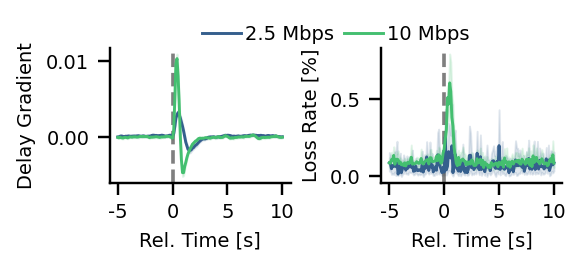

In [36]:
WINDOW_BEFORE = 5
WINDOW_AFTER = 10
GRID_STEP = 0.1
skip_s = 30.0



cmap = plt.cm.viridis
color_one = cmap(0.3)
color_two = cmap(0.7)
tmp_palette=[color_one,color_two]


groups_bitrate_de = [
    {"label": "2.5 Mbps",  "color": tmp_palette[0], "ls": "solid", "measurements": [m for f, m in measurements_2_5.items() if "de-" in f]},
    {"label": "10 Mbps",  "color": tmp_palette[1], "ls": "solid", "measurements": [m for f, m in measurements_10.items() if "de-" in f]},
]


fig, (ax_delay, ax_loss) = plt.subplots(1, 2, figsize=(acm_column_width, 1))
ax_delay.axvline(0, color="black", linewidth=1.5, alpha=0.5, linestyle="--")
ax_loss.axvline(0, color="black", linewidth=1.5, alpha=0.5, linestyle="--")
for g in groups_bitrate_de:
    
    DELAY_ESTIMATE = dict(column="GCCStats.DelayEstimate", kind="value", side="sender", step_ms=GRID_STEP*1000)
    df = epoch_df(g["measurements"], lambda m: get_reconfiguration_times(m,
                                                                         exclude_handovers=False,
                                                                         handover_tolerance_s=1.0,
                                                                         skip_s=skip_s,),
                  WINDOW_BEFORE, WINDOW_AFTER, **DELAY_ESTIMATE)
    
    median, ci_lo, ci_hi = median_ci_df(df)
    t = median.index.total_seconds()
    ax_delay.plot(t, median.values, label=g["label"], color=g["color"], ls=g["ls"])
    ax_delay.fill_between(t, ci_lo.values, ci_hi.values, color=g["color"], alpha=0.15)


    df = epoch_df_custom_for_loss_rate(g["measurements"], lambda m: get_reconfiguration_times(m,
                                                                         exclude_handovers=False,
                                                                         handover_tolerance_s=1.0,
                                                                         skip_s=skip_s,),
                  WINDOW_BEFORE, WINDOW_AFTER)
    mean, ci_lo, ci_hi = mean_ci_df(df)
    t = mean.index.total_seconds()
    ax_loss.plot(t, mean.values, label=g["label"], color=g["color"], ls=g["ls"])
    ax_loss.fill_between(t, ci_lo.values, ci_hi.values, color=g["color"], alpha=0.15)
    


ax_delay.set_ylabel("Delay Gradient")
ax_loss.set_ylabel("Loss Rate [%]")
ax_delay.set_xlabel("Rel. Time [s]")
ax_loss.set_xlabel("Rel. Time [s]")

ax_delay.set_xticks([-5,0,5,10], labels=["-5","0","5","10"])
ax_loss.set_xticks([-5,0,5,10], labels=["-5","0","5","10"])
ax_delay.legend(loc='center', frameon=False, handletextpad=0.2, bbox_to_anchor=(1.25,1.1), ncols=6, columnspacing=0.5)

fig.subplots_adjust(wspace=0.5)
plt.savefig('libwebrtc-de-delay-loss-by-bitrate.pdf', bbox_inches='tight', pad_inches = 0)
plt.show()


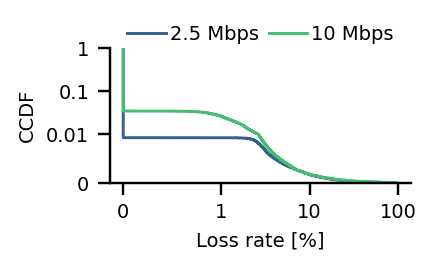

In [37]:
fig, ax = plt.subplots(figsize=(acm_column_width*2/3, 1))

for g in groups_bitrate_de:
    near_rates = []
    far_rates = []
    all_rates = []
    step = "100ms"
    
    for m in g["measurements"]:
        if m.data_parquet_receiver is None:
            continue
        d = m.data_parquet_receiver.data
        if "InboundRTP.PacketsLost" not in d or "InboundRTP.PacketsReceived" not in d:
            continue
        
        lost = d["InboundRTP.PacketsLost"].dropna()
        lost.index = ensure_utc_index(lost.index)
        skip_start = lost.index.min() + pd.Timedelta(seconds=30)
        skip_end = lost.index.max() - pd.Timedelta(seconds=30)
        lost = lost.loc[skip_start:skip_end]

        lost_diff = lost.diff().clip(lower=0).fillna(0)
        
        received = d["InboundRTP.PacketsReceived"].dropna()
        received.index = ensure_utc_index(received.index)
        skip_start = received.index.min() + pd.Timedelta(seconds=30)
        skip_end = received.index.max() - pd.Timedelta(seconds=30)
        received = received.loc[skip_start:skip_end]
        

        resampled_lost = lost.resample(step).max().diff().where(lambda x: x >= 0)
        resampled_received = received.resample(step).max().diff().where(lambda x: x >= 0)
        total_packets = resampled_lost + resampled_received
        rate = (resampled_lost / total_packets).replace([float('inf'), -float('inf')], float('nan')).fillna(0)*100
        
        reconfig_times = [ensure_utc_timestamp(ts) for ts in get_reconfiguration_times(m)]
        
        for ts, val in rate.items():
            all_rates.append(val)
            near = any(0 <= (ts - rt).total_seconds() <= 3 for rt in reconfig_times)
            if near:
                near_rates.append(val)
            else:
                far_rates.append(val)
    
    ax.ecdf(all_rates, color=g["color"], ls="solid", complementary=True, label=g["label"])


ax.set_xlabel("Loss rate [%]")
ax.set_ylabel("CCDF")
ax.legend()
ax.set_xscale("symlog", linthresh=1)
ax.set_yscale("symlog", linthresh=0.01)
ax.yaxis.set_major_formatter(mpl.ticker.FuncFormatter(lambda x, _: f"{x:g}"))
ax.xaxis.set_major_formatter(mpl.ticker.FuncFormatter(lambda x, _: f"{x:g}"))
ax.legend(loc='center', frameon=False, handletextpad=0.2, bbox_to_anchor=(0.5,1.1), ncols=6, columnspacing=0.5)

plt.savefig('libwebrtc-de-tail-loss.pdf', bbox_inches='tight', pad_inches=0)
plt.show()

In [38]:
STEP = "100ms"
EXCEED = reversed([0.001, 0.002, 0.003,0.004,0.005,0.006,0.007, 0.008, 0.009, 0.01])   # CCDF y-levels: P(loss > x)

def collect_rates(measurements):
    out = []
    for m in measurements:
        if m.data_parquet_receiver is None: continue
        d = m.data_parquet_receiver.data
        if "InboundRTP.PacketsLost" not in d or "InboundRTP.PacketsReceived" not in d: continue
        lost = d["InboundRTP.PacketsLost"].dropna()
        lost.index = ensure_utc_index(lost.index)
        skip_start = lost.index.min() + pd.Timedelta(seconds=30)
        skip_end = lost.index.max() - pd.Timedelta(seconds=30)
        lost = lost.loc[skip_start:skip_end]

        recv = d["InboundRTP.PacketsReceived"].dropna()
        recv.index = ensure_utc_index(recv.index)
        skip_start = recv.index.min() + pd.Timedelta(seconds=30)
        skip_end = recv.index.max() - pd.Timedelta(seconds=30)
        recv = recv.loc[skip_start:skip_end]

        rl = lost.resample(STEP).max().diff().where(lambda x: x>=0)
        rr = recv.resample(STEP).max().diff().where(lambda x: x>=0)
        total = rl + rr
        v = rl.notna() & total.notna() & (total > 0)
        out.append((rl[v]/total[v]*100).values)
    return np.concatenate(out)

d = {g["label"]: collect_rates(g["measurements"]) for g in groups_bitrate_de}

# CDF to CCDF -> quantile at 1 - q
print(f"{'P(loss>x)':>10} " + " ".join(f"{l:>10}" for l in d))
for q in EXCEED:
    print(f"{q:>10.4f} " + " ".join(f"{np.quantile(r, 1 - q):>10.2f}" for r in d.values()))

 P(loss>x)   2.5 Mbps    10 Mbps
    0.0100       0.00       2.65
    0.0090       2.44       2.88
    0.0080       2.86       3.12
    0.0070       3.12       3.51
    0.0060       3.57       3.95
    0.0050       4.17       4.59
    0.0040       5.13       5.45
    0.0030       6.67       6.67
    0.0020       9.09       9.01
    0.0010      14.81      15.61


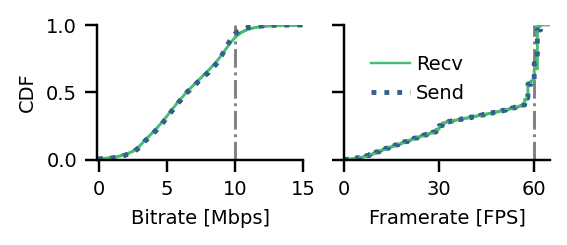

In [39]:
fig, axs = plt.subplots(1, 2, sharey=True, figsize=(acm_column_width, 1))

cmap = plt.cm.viridis
color_1 = cmap(0.3)
color_2 = cmap(0.7)
tmp_palette = [color_2, color_1]


# Received
sns.ecdfplot(ax=axs[0], data=df_metrics_10_starlink[(df_metrics_10_starlink.metric == "recv_bitrate") & (df_metrics_10_starlink.location == "DE")],
             x="value", hue="location", legend=False, hue_order=["DE"], palette=[tmp_palette[0]])
sns.ecdfplot(ax=axs[1], data=df_metrics_10_starlink[(df_metrics_10_starlink.metric == "recv_fps") & (df_metrics_10_starlink.location == "DE")],
             x="value", hue="location", legend=False, hue_order=["DE"], palette=[tmp_palette[0]])

# Sent (dashed)
sns.ecdfplot(ax=axs[0], data=df_metrics_10_starlink[(df_metrics_10_starlink.metric == "send_bitrate") & (df_metrics_10_starlink.location == "DE")],
             x="value", hue="location", legend=False, hue_order=["DE"],
             palette=[tmp_palette[1]], linestyle="dotted", lw=2)
sns.ecdfplot(ax=axs[1], data=df_metrics_10_starlink[(df_metrics_10_starlink.metric == "send_fps") & (df_metrics_10_starlink.location == "DE")],
             x="value", hue="location", legend=False, hue_order=["DE"],
             palette=[tmp_palette[1]], linestyle="dotted",lw=2)

titles = ["", ""]
x_labels = ["Bitrate [Mbps]", "Framerate [FPS]"]
y_labels = ["CDF", ""]
target_rates = [10, 60]

for index, ax in enumerate(axs):
    ax.set_xlim(left=-0.1)
    ax.set_title(titles[index])
    ax.set_xlabel(x_labels[index])
    ax.set_ylabel(y_labels[index])
    ax.axvline(target_rates[index], color="gray", ls="-.", zorder=-1)
    if index != 0:
        ax.tick_params(labelleft=False)
    if index == 1:
        legend_handles = [
            mpl.lines.Line2D([0], [0], color=tmp_palette[0], label="Recv", markersize=2, lw=1),
            mpl.lines.Line2D([0], [0], color=tmp_palette[1], label="Send", markersize=2, lw=2, linestyle="dotted"),
        ]
        ax.legend(handles=legend_handles, loc='center', frameon=False,
                  handletextpad=0.3, bbox_to_anchor=(0.36, 0.6))

axs[0].set_xlim(left=-0.1, right=15)
axs[1].set_xlim(left=0, right=65)
axs[0].set_xticks([0,5,10,15], labels=["0","5","10","15"])
axs[1].set_xticks([0,30,60], labels=["0","30","60"])
plt.savefig('libwebrtc-de-10.pdf', bbox_inches='tight', pad_inches=0)
plt.show()

In [40]:
measurements = [m for f, m in measurements_10.items() if "de-" in f]

total_duration_s = 0
overuse_duration_s = 0
decreasing_duration_s = 0

for m in measurements:
    usage = get_delay_based_usage(m)
    if usage is None:
        continue
    
    dt = usage.index.to_series().diff().dt.total_seconds().fillna(0)
    total_duration_s += dt.sum()
    overuse_duration_s += dt[usage == 2].sum()
    
    if m.data_parquet_sender is not None and "GCCStats.State" in m.data_parquet_sender.data:
        state = m.data_parquet_sender.data["GCCStats.State"]
        state = state.copy()
        state.index = ensure_utc_index(state.index)
        skip_start = state.index.min() + pd.Timedelta(seconds=30)
        skip_end = state.index.max() - pd.Timedelta(seconds=30)
        state = state.loc[skip_start:skip_end]
        dt_state = state.index.to_series().diff().dt.total_seconds().fillna(0)
        decreasing_duration_s += dt_state[state == "decreasing"].sum()

print("DE 10 Mbps")
print(f"  Total duration:      {total_duration_s:.0f}s ({total_duration_s/3600:.1f}h)")
print(f"  Delay overuse:       {overuse_duration_s:.1f}s ({100 * overuse_duration_s / total_duration_s:.2f}%)")
print(f"  Loss decreasing:     {decreasing_duration_s:.1f}s ({100 * decreasing_duration_s / total_duration_s:.2f}%)")

DE 10 Mbps
  Total duration:      43650s (12.1h)
  Delay overuse:       199.9s (0.46%)
  Loss decreasing:     2018.4s (4.62%)


# Pion 10 Mbps no CC


In [41]:

paths = ["../data/libwebrtc-and-pion/de-pion-no-cc-10/"]

folders = []

for path in paths:
    for folder in [f.path for f in os.scandir(path) if f.is_dir()]:
        folders.append(folder)

measurements_10_pion_no_cc= dict()
for folder in folders:
    sender_parquet = os.path.join(folder, "sender.parquet")
    receiver_parquet = os.path.join(folder, "receiver.parquet")
    if not (os.path.exists(sender_parquet) and os.path.exists(receiver_parquet)):
        print(f"Skipping {folder}: missing sender.parquet or receiver.parquet")
        continue
    try:
        measurement = Measurement(folder)
        measurement.load_files()
        measurements_10_pion_no_cc[folder] = measurement
    except Exception as e:
        print(f"Warning: {e}")

measurements_10_pion_no_cc

Loading Dishy data from file: ../data/libwebrtc-and-pion/de-pion-no-cc-10/video-Pion-NoCC-10000-1777053935/dishy_sender.json
Loading IRTT data from file: ../data/libwebrtc-and-pion/de-pion-no-cc-10/video-Pion-NoCC-10000-1777053935/irtt-sender.json
Loading Parquet data from file: ../data/libwebrtc-and-pion/de-pion-no-cc-10/video-Pion-NoCC-10000-1777053935/sender.parquet
Loading Parquet data from file: ../data/libwebrtc-and-pion/de-pion-no-cc-10/video-Pion-NoCC-10000-1777053935/receiver.parquet
Loading Dishy data from file: ../data/libwebrtc-and-pion/de-pion-no-cc-10/video-Pion-NoCC-10000-1777176335/dishy_sender.json
Loading IRTT data from file: ../data/libwebrtc-and-pion/de-pion-no-cc-10/video-Pion-NoCC-10000-1777176335/irtt-sender.json
Loading Parquet data from file: ../data/libwebrtc-and-pion/de-pion-no-cc-10/video-Pion-NoCC-10000-1777176335/sender.parquet
Loading Parquet data from file: ../data/libwebrtc-and-pion/de-pion-no-cc-10/video-Pion-NoCC-10000-1777176335/receiver.parquet
Load

{'../data/libwebrtc-and-pion/de-pion-no-cc-10/video-Pion-NoCC-10000-1777053935': <loaders.measurement.Measurement at 0x33c5b9540>,
 '../data/libwebrtc-and-pion/de-pion-no-cc-10/video-Pion-NoCC-10000-1777176335': <loaders.measurement.Measurement at 0x333d8cb50>,
 '../data/libwebrtc-and-pion/de-pion-no-cc-10/video-Pion-NoCC-10000-1777032473': <loaders.measurement.Measurement at 0x32b357700>,
 '../data/libwebrtc-and-pion/de-pion-no-cc-10/video-Pion-NoCC-10000-1777183535': <loaders.measurement.Measurement at 0x333d5f250>,
 '../data/libwebrtc-and-pion/de-pion-no-cc-10/video-Pion-NoCC-10000-1777075535': <loaders.measurement.Measurement at 0x32c71bcd0>,
 '../data/libwebrtc-and-pion/de-pion-no-cc-10/video-Pion-NoCC-10000-1777068335': <loaders.measurement.Measurement at 0x3349acb80>,
 '../data/libwebrtc-and-pion/de-pion-no-cc-10/video-Pion-NoCC-10000-1777089935': <loaders.measurement.Measurement at 0x31f31d6f0>,
 '../data/libwebrtc-and-pion/de-pion-no-cc-10/video-Pion-NoCC-10000-1777046736': <l

In [42]:
resample_ms = 100
trim_start = 30
trim_end = 30

METRICS = {
    "send_bitrate":       lambda m: gather_sent_bitrate_samples_trimmed(m, resample_ms, trim_start, trim_end),
    "recv_bitrate":       lambda m: gather_recv_bitrate_samples_trimmed(m, resample_ms, trim_start, trim_end),
}

SITES = {"aq-": "AQ", "de-": "DE", "nl-": "NL", "no-": "NO"}

def site_of(folder):
    return next((v for k, v in SITES.items() if k in folder), None)

def collect(measurements, metrics=METRICS, require_all=True):
    rows, durations, skipped = [], [], []
    for folder, m in measurements.items():
        try:
            vals = {k: fn(m) for k, fn in metrics.items()}
            dur  = measurement_parquet_receiver_msm_duration(m)
        except Exception as exc:
            skipped.append((folder, repr(exc)))
            continue
        missing = [k for k, v in vals.items() if not v]
        if dur is None or (require_all and missing):
            skipped.append((folder, f"missing: {missing or ['duration']}"))
            continue
        for name, v in vals.items():
            rows.append(pd.DataFrame({"value": v, "metric": name, "folder": folder}))
        durations.append({"folder": folder, "duration": dur})
    print(skipped)
    long = pd.concat(rows, ignore_index=True)
    long["location"] = long["folder"].map(site_of)
    dur = pd.DataFrame(durations)
    dur["location"] = dur["folder"].map(site_of)

    print(f"used {dur.shape[0]} folders, skipped {len(skipped)}")
    for f, why in skipped:
        print(f"  {f}: {why}")
    unmatched = long.loc[long.location.isna(), "folder"].unique()
    if len(unmatched):
        print(f"  no site match: {list(unmatched)}")
    return long, dur

df_metrics_10_pion_nocc_starlink, df_duration_10_pion_nocc_starlink = collect(measurements_10_pion_no_cc)

[]
used 16 folders, skipped 0


# Pion 10 Mbps scream


In [43]:
paths = ["../data/libwebrtc-and-pion/de-pion-scream-10/"]

folders = []

for path in paths:
    for folder in [f.path for f in os.scandir(path) if f.is_dir()]:
        folders.append(folder)

measurements_10_pion_scream= dict()
for folder in folders:
    sender_parquet = os.path.join(folder, "sender.parquet")
    receiver_parquet = os.path.join(folder, "receiver.parquet")
    if not (os.path.exists(sender_parquet) and os.path.exists(receiver_parquet)):
        print(f"Skipping {folder}: missing sender.parquet or receiver.parquet")
        continue
    try:
        measurement = Measurement(folder)
        measurement.load_files()
        measurements_10_pion_scream[folder] = measurement
    except Exception as e:
        print(f"Warning: {e}")

measurements_10_pion_scream

Loading Dishy data from file: ../data/libwebrtc-and-pion/de-pion-scream-10/video-Pion-SCReAM-10000-1777033391/dishy_sender.json
Loading IRTT data from file: ../data/libwebrtc-and-pion/de-pion-scream-10/video-Pion-SCReAM-10000-1777033391/irtt-sender.json
Loading Parquet data from file: ../data/libwebrtc-and-pion/de-pion-scream-10/video-Pion-SCReAM-10000-1777033391/sender.parquet
Loading Parquet data from file: ../data/libwebrtc-and-pion/de-pion-scream-10/video-Pion-SCReAM-10000-1777033391/receiver.parquet
Loading Dishy data from file: ../data/libwebrtc-and-pion/de-pion-scream-10/video-Pion-SCReAM-10000-1777162845/dishy_sender.json
Loading IRTT data from file: ../data/libwebrtc-and-pion/de-pion-scream-10/video-Pion-SCReAM-10000-1777162845/irtt-sender.json
Loading Parquet data from file: ../data/libwebrtc-and-pion/de-pion-scream-10/video-Pion-SCReAM-10000-1777162845/sender.parquet
Loading Parquet data from file: ../data/libwebrtc-and-pion/de-pion-scream-10/video-Pion-SCReAM-10000-17771628

{'../data/libwebrtc-and-pion/de-pion-scream-10/video-Pion-SCReAM-10000-1777033391': <loaders.measurement.Measurement at 0x330b48910>,
 '../data/libwebrtc-and-pion/de-pion-scream-10/video-Pion-SCReAM-10000-1777162845': <loaders.measurement.Measurement at 0x31a081630>,
 '../data/libwebrtc-and-pion/de-pion-scream-10/video-Pion-SCReAM-10000-1777119545': <loaders.measurement.Measurement at 0x330bc0520>,
 '../data/libwebrtc-and-pion/de-pion-scream-10/video-Pion-SCReAM-10000-1777040459': <loaders.measurement.Measurement at 0x33a4b0f70>,
 '../data/libwebrtc-and-pion/de-pion-scream-10/video-Pion-SCReAM-10000-1777191657': <loaders.measurement.Measurement at 0x31e618a60>,
 '../data/libwebrtc-and-pion/de-pion-scream-10/video-Pion-SCReAM-10000-1777054848': <loaders.measurement.Measurement at 0x323212b90>,
 '../data/libwebrtc-and-pion/de-pion-scream-10/video-Pion-SCReAM-10000-1777105248': <loaders.measurement.Measurement at 0x31a0c2b30>,
 '../data/libwebrtc-and-pion/de-pion-scream-10/video-Pion-SCRe

In [44]:

df_metrics_10_pion_scream_starlink, df_duration_10_pion_scream_starlink = collect(measurements_10_pion_scream)

[]
used 23 folders, skipped 0


# Pion 2.5 Mbps no CC


In [45]:
paths = ["../data/libwebrtc-and-pion/de-pion-no-cc-2_5/"]

folders = []

for path in paths:
    for folder in [f.path for f in os.scandir(path) if f.is_dir()]:
        folders.append(folder)

measurements_2_5_pion_no_cc= dict()
for folder in folders:
    sender_parquet = os.path.join(folder, "sender.parquet")
    receiver_parquet = os.path.join(folder, "receiver.parquet")
    if not (os.path.exists(sender_parquet) and os.path.exists(receiver_parquet)):
        print(f"Skipping {folder}: missing sender.parquet or receiver.parquet")
        continue
    try:
        measurement = Measurement(folder)
        measurement.load_files()
        measurements_2_5_pion_no_cc[folder] = measurement
    except Exception as e:
        print(f"Warning: {e}")

measurements_2_5_pion_no_cc

Loading Dishy data from file: ../data/libwebrtc-and-pion/de-pion-no-cc-2_5/video-Pion-NoCC-2500-1777178157/dishy_sender.json
Loading IRTT data from file: ../data/libwebrtc-and-pion/de-pion-no-cc-2_5/video-Pion-NoCC-2500-1777178157/irtt-sender.json
Loading Parquet data from file: ../data/libwebrtc-and-pion/de-pion-no-cc-2_5/video-Pion-NoCC-2500-1777178157/sender.parquet
Loading Parquet data from file: ../data/libwebrtc-and-pion/de-pion-no-cc-2_5/video-Pion-NoCC-2500-1777178157/receiver.parquet
Loading Dishy data from file: ../data/libwebrtc-and-pion/de-pion-no-cc-2_5/video-Pion-NoCC-2500-1777055766/dishy_sender.json
Loading IRTT data from file: ../data/libwebrtc-and-pion/de-pion-no-cc-2_5/video-Pion-NoCC-2500-1777055766/irtt-sender.json
Loading Parquet data from file: ../data/libwebrtc-and-pion/de-pion-no-cc-2_5/video-Pion-NoCC-2500-1777055766/sender.parquet
Loading Parquet data from file: ../data/libwebrtc-and-pion/de-pion-no-cc-2_5/video-Pion-NoCC-2500-1777055766/receiver.parquet
Load

{'../data/libwebrtc-and-pion/de-pion-no-cc-2_5/video-Pion-NoCC-2500-1777178157': <loaders.measurement.Measurement at 0x32d6a7f40>,
 '../data/libwebrtc-and-pion/de-pion-no-cc-2_5/video-Pion-NoCC-2500-1777055766': <loaders.measurement.Measurement at 0x334fa4070>,
 '../data/libwebrtc-and-pion/de-pion-no-cc-2_5/video-Pion-NoCC-2500-1777127658': <loaders.measurement.Measurement at 0x320e3bd60>,
 '../data/libwebrtc-and-pion/de-pion-no-cc-2_5/video-Pion-NoCC-2500-1777170961': <loaders.measurement.Measurement at 0x31fc692d0>,
 '../data/libwebrtc-and-pion/de-pion-no-cc-2_5/video-Pion-NoCC-2500-1777070162': <loaders.measurement.Measurement at 0x336094f70>,
 '../data/libwebrtc-and-pion/de-pion-no-cc-2_5/video-Pion-NoCC-2500-1777048561': <loaders.measurement.Measurement at 0x32472a470>,
 '../data/libwebrtc-and-pion/de-pion-no-cc-2_5/video-Pion-NoCC-2500-1777113364': <loaders.measurement.Measurement at 0x32477aa40>,
 '../data/libwebrtc-and-pion/de-pion-no-cc-2_5/video-Pion-NoCC-2500-1777084558': <l

In [46]:


df_metrics_2_5_pion_nocc_starlink, df_duration_2_5_pion_nocc_starlink = collect(measurements_2_5_pion_no_cc)

[]
used 22 folders, skipped 0


# Pion 2.5 Mbps scream


In [47]:
paths = ["../data/libwebrtc-and-pion/de-pion-scream-2_5/"]

folders = []

for path in paths:
    for folder in [f.path for f in os.scandir(path) if f.is_dir()]:
        folders.append(folder)

measurements_2_5_pion_scream= dict()
for folder in folders:
    sender_parquet = os.path.join(folder, "sender.parquet")
    receiver_parquet = os.path.join(folder, "receiver.parquet")
    if not (os.path.exists(sender_parquet) and os.path.exists(receiver_parquet)):
        print(f"Skipping {folder}: missing sender.parquet or receiver.parquet")
        continue
    try:
        measurement = Measurement(folder)
        measurement.load_files()
        measurements_2_5_pion_scream[folder] = measurement
    except Exception as e:
        print(f"Warning: {e}")

measurements_2_5_pion_scream

Loading Dishy data from file: ../data/libwebrtc-and-pion/de-pion-scream-2_5/video-Pion-SCReAM-2500-1777092684/dishy_sender.json
Loading IRTT data from file: ../data/libwebrtc-and-pion/de-pion-scream-2_5/video-Pion-SCReAM-2500-1777092684/irtt-sender.json
Loading Parquet data from file: ../data/libwebrtc-and-pion/de-pion-scream-2_5/video-Pion-SCReAM-2500-1777092684/sender.parquet
Loading Parquet data from file: ../data/libwebrtc-and-pion/de-pion-scream-2_5/video-Pion-SCReAM-2500-1777092684/receiver.parquet
Loading Dishy data from file: ../data/libwebrtc-and-pion/de-pion-scream-2_5/video-Pion-SCReAM-2500-1777071075/dishy_sender.json
Loading IRTT data from file: ../data/libwebrtc-and-pion/de-pion-scream-2_5/video-Pion-SCReAM-2500-1777071075/irtt-sender.json
Loading Parquet data from file: ../data/libwebrtc-and-pion/de-pion-scream-2_5/video-Pion-SCReAM-2500-1777071075/sender.parquet
Loading Parquet data from file: ../data/libwebrtc-and-pion/de-pion-scream-2_5/video-Pion-SCReAM-2500-17770710

{'../data/libwebrtc-and-pion/de-pion-scream-2_5/video-Pion-SCReAM-2500-1777092684': <loaders.measurement.Measurement at 0x320520430>,
 '../data/libwebrtc-and-pion/de-pion-scream-2_5/video-Pion-SCReAM-2500-1777071075': <loaders.measurement.Measurement at 0x335a6a6b0>,
 '../data/libwebrtc-and-pion/de-pion-scream-2_5/video-Pion-SCReAM-2500-1777186271': <loaders.measurement.Measurement at 0x3345abb20>,
 '../data/libwebrtc-and-pion/de-pion-scream-2_5/video-Pion-SCReAM-2500-1777114276': <loaders.measurement.Measurement at 0x333d4a0e0>,
 '../data/libwebrtc-and-pion/de-pion-scream-2_5/video-Pion-SCReAM-2500-1777107070': <loaders.measurement.Measurement at 0x324725030>,
 '../data/libwebrtc-and-pion/de-pion-scream-2_5/video-Pion-SCReAM-2500-1777056686': <loaders.measurement.Measurement at 0x3247cf1f0>,
 '../data/libwebrtc-and-pion/de-pion-scream-2_5/video-Pion-SCReAM-2500-1777085470': <loaders.measurement.Measurement at 0x32c560100>,
 '../data/libwebrtc-and-pion/de-pion-scream-2_5/video-Pion-SCR

In [48]:


df_metrics_2_5_pion_scream_starlink, df_duration_2_5_pion_scream_starlink = collect(measurements_2_5_pion_scream)

[]
used 17 folders, skipped 0


In [49]:
for df_tmp, config in [(df_duration_10_starlink, "libwebrtc 10"),
                (df_duration_10_pion_nocc_starlink, "pion nocc 10"),
                (df_duration_10_pion_scream_starlink, "pion scream 10"),
                (df_duration_2_5_pion_nocc_starlink, "pion nocc 2.5"),
                (df_duration_2_5_pion_scream_starlink, "pion scream 2.5")]:
    print(config)
    df_tmp["day"] = df_tmp["folder"].apply(lambda x: pd.to_datetime(x.split("-")[-1], unit="s").strftime("%Y-%m-%d"))
    df_tmp["month"] = df_tmp["folder"].apply(lambda x: pd.to_datetime(x.split("-")[-1], unit="s").strftime("%Y-%m"))
    print(df_tmp.groupby("location").agg({"day":lambda x: ",".join(sorted(pd.Series.unique(x)))}))
    print(df_tmp.groupby("location").agg({"duration": lambda x: sum(x)/3600}))
    print(df_tmp.groupby(["location", "month"]).agg({"duration": lambda x: sum(x)/3600}))

libwebrtc 10
                                                                                   day
location                                                                              
DE        2025-11-16,2025-11-17,2025-11-18,2025-11-19,2026-01-23,2026-01-24,2026-04-29
           duration
location           
DE        12.991818
                  duration
location month            
DE       2025-11  8.494271
         2026-01  3.248427
         2026-04  1.249120
pion nocc 10
                                       day
location                                  
DE        2026-04-24,2026-04-25,2026-04-26
          duration
location          
DE          3.9961
                  duration
location month            
DE       2026-04    3.9961
pion scream 10
                                       day
location                                  
DE        2026-04-24,2026-04-25,2026-04-26
          duration
location          
DE        5.519395
                  duration
location month         

/var/folders/ch/9cq6nnj5671_t9s55m2sc0400000gn/T/ipykernel_87518/3132746134.py:7: FutureWarning: The behavior of 'to_datetime' with 'unit' when parsing strings is deprecated. In a future version, strings will be parsed as datetime strings, matching the behavior without a 'unit'. To retain the old behavior, explicitly cast ints or floats to numeric type before calling to_datetime.
  df_tmp["day"] = df_tmp["folder"].apply(lambda x: pd.to_datetime(x.split("-")[-1], unit="s").strftime("%Y-%m-%d"))
/var/folders/ch/9cq6nnj5671_t9s55m2sc0400000gn/T/ipykernel_87518/3132746134.py:8: FutureWarning: The behavior of 'to_datetime' with 'unit' when parsing strings is deprecated. In a future version, strings will be parsed as datetime strings, matching the behavior without a 'unit'. To retain the old behavior, explicitly cast ints or floats to numeric type before calling to_datetime.
  df_tmp["month"] = df_tmp["folder"].apply(lambda x: pd.to_datetime(x.split("-")[-1], unit="s").strftime("%Y-%m"))
/va

In [50]:
df_tmp = pd.DataFrame(df_metrics_2_5_starlink[(df_metrics_2_5_starlink.location == "DE") & (df_metrics_2_5_starlink.metric == "recv_bitrate")]["value"].copy())
df_tmp.rename({"value":"bitrate"}, inplace=True)
df_tmp["CCA"] = "GCC"


df_2500kbps = df_tmp


df_tmp = pd.DataFrame(df_metrics_10_starlink[(df_metrics_10_starlink.location == "DE") & (df_metrics_10_starlink.metric == "recv_bitrate")]["value"].copy())
df_tmp.rename({"value":"bitrate"}, inplace=True)
df_tmp["CCA"] = "GCC"

df_10000kbps = df_tmp

df_tmp = pd.DataFrame(df_metrics_10_pion_nocc_starlink[(df_metrics_10_pion_nocc_starlink.location == "DE") & (df_metrics_10_pion_nocc_starlink.metric == "recv_bitrate")]["value"].copy())
df_tmp.rename({"value":"bitrate"}, inplace=True)
df_tmp["CCA"] = "No-CC"

df_10000kbps = pd.concat([df_10000kbps, df_tmp])


df_tmp = pd.DataFrame(df_metrics_2_5_pion_nocc_starlink[(df_metrics_2_5_pion_nocc_starlink.location == "DE") & (df_metrics_2_5_pion_nocc_starlink.metric == "recv_bitrate")]["value"].copy())
df_tmp.rename({"value":"bitrate"}, inplace=True)
df_tmp["CCA"] = "No-CC"

df_2500kbps = pd.concat([df_2500kbps, df_tmp])


df_tmp = pd.DataFrame(df_metrics_10_pion_scream_starlink[(df_metrics_10_pion_scream_starlink.location == "DE") & (df_metrics_10_pion_scream_starlink.metric == "recv_bitrate")]["value"].copy())
df_tmp.rename({"value":"bitrate"}, inplace=True)
df_tmp["CCA"] = "SCReAMv1"

df_10000kbps = pd.concat([df_10000kbps, df_tmp])


df_tmp = pd.DataFrame(df_metrics_2_5_pion_scream_starlink[(df_metrics_2_5_pion_scream_starlink.location == "DE") & (df_metrics_2_5_pion_scream_starlink.metric == "recv_bitrate")]["value"].copy())
df_tmp.rename({"value":"bitrate"}, inplace=True)
df_tmp["CCA"] = "SCReAMv1"

df_2500kbps = pd.concat([df_2500kbps, df_tmp])



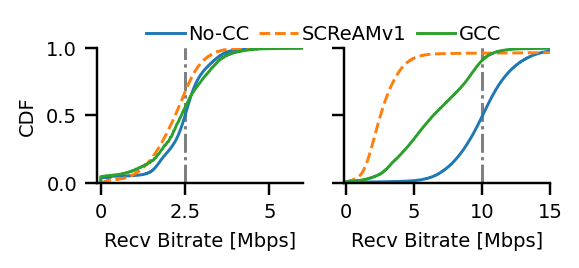

In [51]:
fig, axs = plt.subplots(1, 2, sharey=True, figsize=(acm_column_width, 1))

linestyles = ["solid", "dashed", "solid"]
dataframes = [df_2500kbps, df_10000kbps]
target_rates = [2.5, 10]
legend_items = ["No-CC","SCReAMv1", "GCC"]


for color_index, experiment in enumerate(legend_items):
    for index, ax in enumerate(axs):
        subset = dataframes[index][dataframes[index]["CCA"] == experiment]["value"]
        if not subset.empty:
            ax.ecdf(subset, label=experiment, color=f"C{color_index}", ls=linestyles[color_index])

for index, ax in enumerate(axs):
    ax.set_xlim(left=-0.1)
    ax.set_xlabel("Bitrate [Mbps]")
    ax.set_ylabel("CDF" if index == 0 else "")
    ax.axvline(target_rates[index], color="gray", ls="-.", zorder=-1)
    if index != 0:
        ax.tick_params(labelleft=False)
titles = ["", ""]
x_labels = ["Recv Bitrate [Mbps]", "Recv Bitrate [Mbps]"]
y_labels = ["CDF", ""]
target_rates = [2.5, 10]

for index, ax in enumerate(axs):
    ax.set_xlim(left=-0.1)
    ax.set_xlabel(x_labels[index])
    ax.set_ylabel(y_labels[index])
    ax.axvline(target_rates[index], color="gray", ls="-.", zorder=-1)
    if index != 0:
        ax.tick_params(labelleft=False)
    if index == 0:
        ax.legend(loc='center', frameon=False, handletextpad=0.2, bbox_to_anchor=(1.1,1.1), ncols=4, columnspacing=0.5)
axs[0].set_xlim(left=-.1,right=6)
axs[0].set_xticks(ticks=[0,2.5,5], labels=["0", "2.5", "5"])
axs[1].set_xlim(left=-.1,right=15)
axs[1].set_xticks([0,5,10,15], labels=["0","5","10","15"])
plt.savefig('pion-de.pdf', bbox_inches='tight', pad_inches=0)
plt.show()